In [2]:
import numpy as np
import pandas as pd 

In [3]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\archive (18)\IBM__Telco-Customer-Churn.csv")


df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# changing dtype "totalcharging"

In [6]:
print(df['TotalCharges'].unique()[:20])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']


In [7]:
# Replace empty spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Check how many nulls created
print(df['TotalCharges'].isnull().sum())

11


In [8]:
# Fill nulls with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [9]:
print(df['TotalCharges'].dtype)

float64


In [10]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
churn_rate = (df['Churn'].sum() / len(df)) * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


Out of 7,043 customers, 1,869 have churned — giving an overall churn rate of 26.5%. This means 1 in 4 customers is leaving the business — a significant revenue loss that needs immediate attention.

# churn by contract type

In [13]:
print(df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


# churn by payment method

In [14]:
print(df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False) * 100)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


# churn by internet service

In [15]:
print(df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False) * 100)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


# Recommendation 1 — Push Annual Contracts

Month-to-month customers churn at 43% vs only 3% for two year contracts. Offering a 10-15% discount to switch to annual contracts could reduce overall churn by 8-10% — saving the business significant recurring revenue

# Recommendation 2 — Promote Auto Payments

Electronic check users churn at 45% vs 15% for automatic payment users — a 3x difference. Offering $5 monthly discount for switching to auto pay could reduce churn by 5-7%.

# Recommendation 3 — Fix Fiber Optic Value
Fiber optic customers churn at 42% despite paying premium prices. Since they represent highest revenue per customer, even a 10% reduction in Fiber optic churn would have outsized revenue impact.

# churn by tenure

In [22]:
df['tenure_group'] = pd.cut(df['tenure'], 
                    bins=[0,12,24,48,72], 
                    labels=['0-1yr','1-2yr','2-4yr','4-6yr'])
print(df.groupby('tenure_group')['Churn'].mean().sort_values(ascending=False) * 100)

tenure_group
0-1yr    47.678161
1-2yr    28.710938
2-4yr    20.388959
4-6yr     9.513176
Name: Churn, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_8028\3401731719.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('tenure_group')['Churn'].mean().sort_values(ascending=False) * 100)


# churn by monthly charges

In [23]:
df['charge_group'] = pd.cut(df['MonthlyCharges'],
                    bins=[0,30,60,90,120],
                    labels=['Low','Medium','High','Very High'])
print(df.groupby('charge_group')['Churn'].mean().sort_values(ascending=False) * 100)

charge_group
High         33.906119
Very High    32.777458
Medium       25.928854
Low           9.800363
Name: Churn, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_8028\3899614849.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('charge_group')['Churn'].mean().sort_values(ascending=False) * 100)


# Recommendation 4 — First Year Retention Program

48% of customers churn within first 12 months — nearly 1 in 2 new customers leave. A structured onboarding program with a free upgrade in months 1-3 could cut first year churn in half.

# Recommendation 5 — Retain High Value Customers
Customers paying $60+ monthly churn at 33% — the highest revenue risk segment. A proactive retention call or personalized offer before month 6 could save the business's most valuable customers

In [24]:
df.to_csv('telco_churn_cleaned.csv', index=False)
print("Saved!")

Saved!


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Visual Analysis

# Overall Churn Count

C:\Users\Admin\AppData\Local\Temp\ipykernel_8028\365548076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['green','red'])


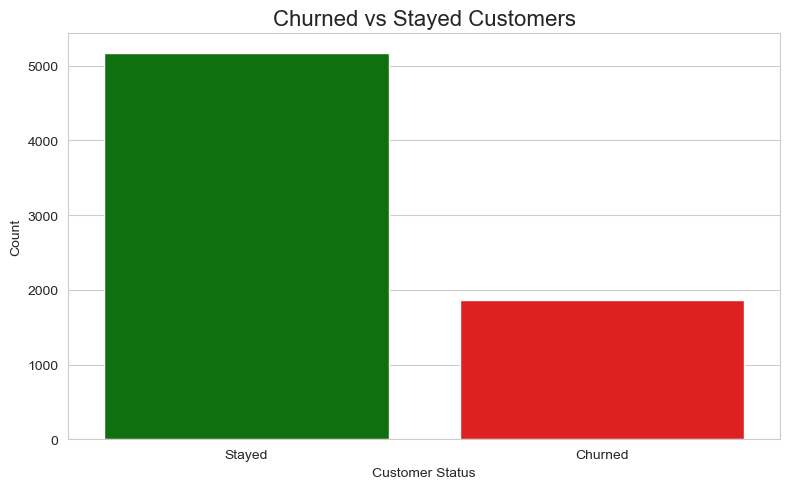

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='Churn', data=df, palette=['green','red'])
plt.title('Churned vs Stayed Customers', fontsize=16)
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_overview.png')
plt.show()

# Churn by Contract Type

C:\Users\Admin\AppData\Local\Temp\ipykernel_8028\255507789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_churn.index, y=contract_churn.values, palette='Reds_r')


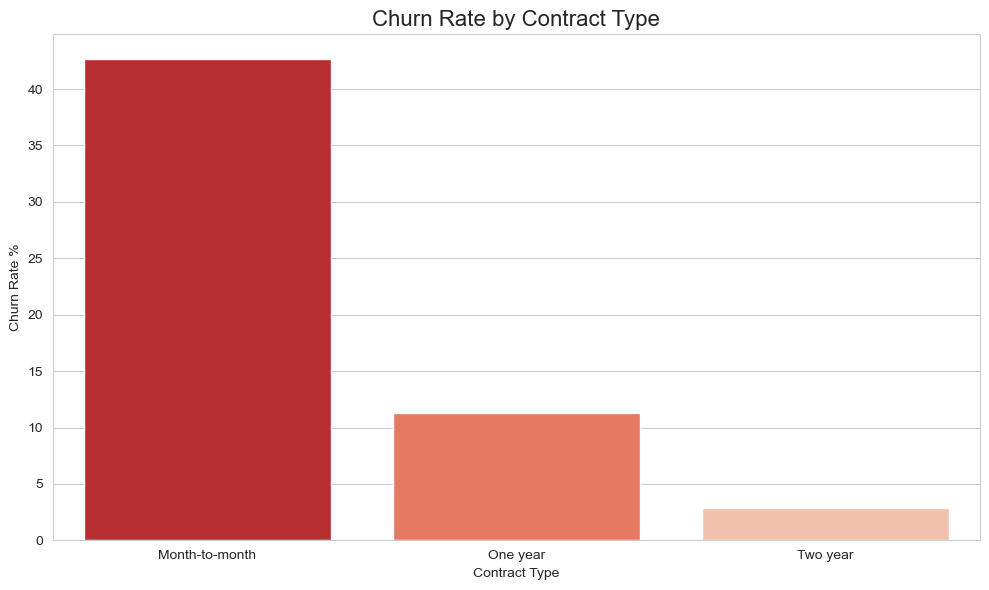

In [28]:
plt.figure(figsize=(10,6))
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
sns.barplot(x=contract_churn.index, y=contract_churn.values, palette='Reds_r')
plt.title('Churn Rate by Contract Type', fontsize=16)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate %')
plt.tight_layout()
plt.savefig('churn_by_contract.png')
plt.show()

# Churn by Internet Service

C:\Users\Admin\AppData\Local\Temp\ipykernel_8028\2504614989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=internet_churn.index, y=internet_churn.values, palette='Oranges_r')


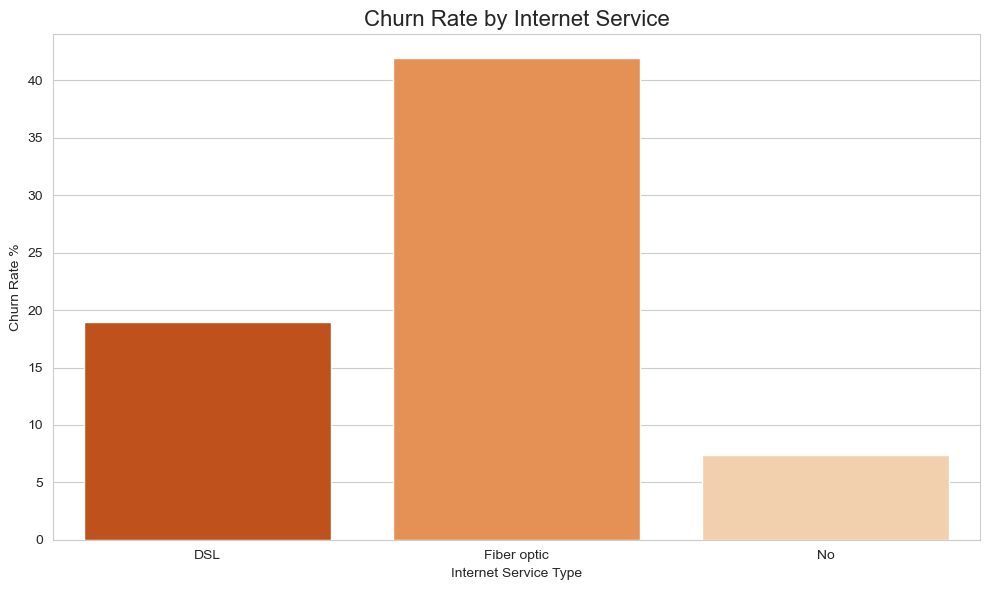

In [29]:
plt.figure(figsize=(10,6))
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
sns.barplot(x=internet_churn.index, y=internet_churn.values, palette='Oranges_r')
plt.title('Churn Rate by Internet Service', fontsize=16)
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate %')
plt.tight_layout()
plt.savefig('churn_by_internet.png')
plt.show()

# Tenure Distribution

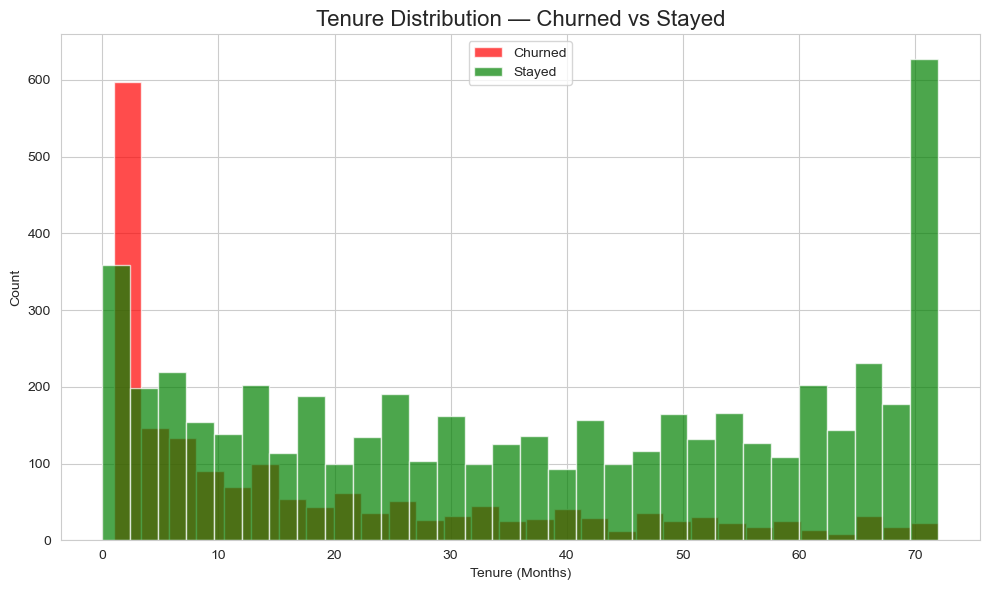

In [32]:
plt.figure(figsize=(10,6))
df[df['Churn']==1]['tenure'].hist(alpha=0.7, color='red', label='Churned', bins=30)
df[df['Churn']==0]['tenure'].hist(alpha=0.7, color='green', label='Stayed', bins=30)
plt.title('Tenure Distribution — Churned vs Stayed', fontsize=16)
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('tenure_distribution.png')
plt.show()

#  Monthly Charges Box Plot

C:\Users\Admin\AppData\Local\Temp\ipykernel_8028\468935976.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['green','red'])


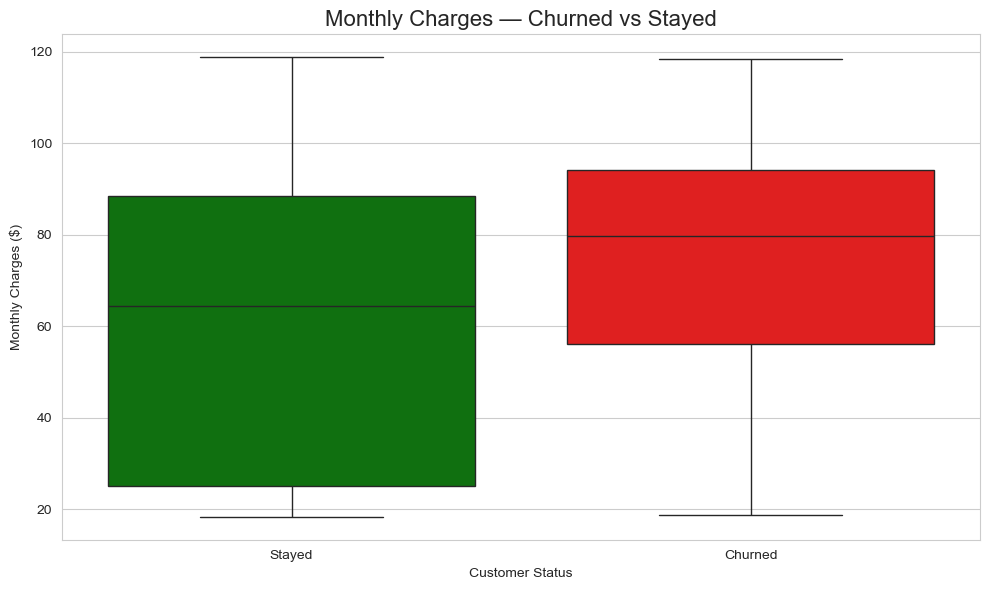

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['green','red'])
plt.title('Monthly Charges — Churned vs Stayed', fontsize=16)
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('monthly_charges_boxplot.png')
plt.show()

# Correlation Heatmap

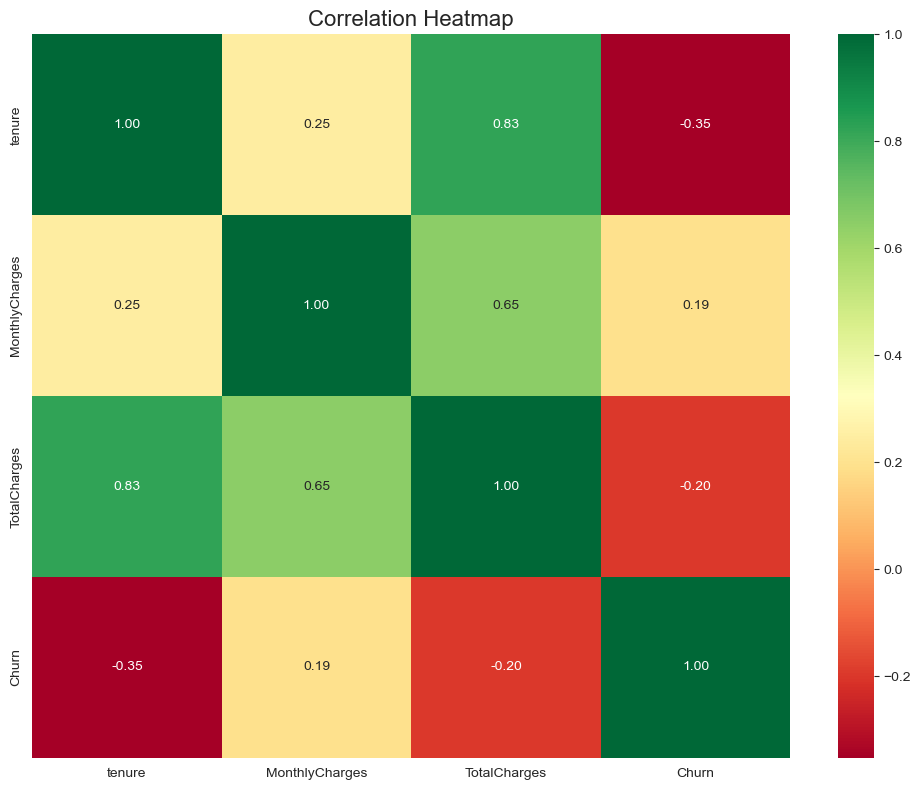

In [34]:
plt.figure(figsize=(10,8))
numeric_cols = df[['tenure','MonthlyCharges','TotalCharges','Churn']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [35]:
df['Churn_Label'] = df['Churn'].map({1: 'Churned', 0: 'Stayed'})
df.to_csv('telco_churn_cleaned.csv', index=False)
print("Done!")

Done!
